# 02 — Feature Engineering (4 Groups, 330 features)

**Composition (A, 71)** | **Precipitation (B, 198)** | **Process (C, 16)** | **Physics (D, 45)**

**4-group structure**:
- **A. Composition** (71): solutes(14) + Magpie stats(30) + stoichiometry(7) + valence(4) + global(10) + orbital(6) + alloy class(7) + solid solution(4)
- **B. Precipitation** (198): named interactions(14) + pair products(91) + solute/Al ratios(14) + precipitate potentials(13) + kinetics(8) + CxP(45) + wrought(13)
- **C. Process** (16): raw params(3) + transforms(13)
- **D. Physics** (45): thermodynamics(9) + elastic(7) + kinetic(5) + full-alloy(8) + delta-to-Al(16)

**Input**: `data/metal_cleaned.csv`, `data/metal_train_imputed.csv`, `data/metal_holdout_imputed.csv`

**Output**:
- `X.npy`, `y.npy` — full dataset (NaN preserved, for N04 Phase B 50-split)
- `X_train.npy`, `y_train.npy` — train set (seed=42, imputed, for N03 + N04 Phase A)
- `X_test.npy`, `y_test.npy` — test set (seed=42, imputed, for N04 Phase A evaluation)
- `feature_meta.json` — feature names + group mapping
- `optimal_features.json` — per-target optimal feature indices (from ablation, for N03)
- `figure/pca_train_test.pdf` — PCA train vs test distribution plot

In [1]:
import os, json, warnings, numpy as np, pandas as pd
warnings.filterwarnings('ignore')

RNG_SEED = 42; np.random.seed(RNG_SEED)
DATA_DIR = os.path.join('..', 'data')
os.makedirs(os.path.join('..', 'figure'), exist_ok=True)

MASS_FRAC_COLS = ['Si','Fe','Cu','Mn','Mg','Cr','Zn','V','Ti','Zr','Li','Ni','Be','Sc']
PROCESS_COLS   = ['Tsol','Tage','tage']
TARGET_COLS    = ['YS','UTS','El']

## 1. Load All Data

In [2]:
# Load all three datasets
df_full = pd.read_csv(os.path.join(DATA_DIR, 'metal_cleaned.csv'))
df_train = pd.read_csv(os.path.join(DATA_DIR, 'metal_train_imputed.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'metal_holdout_imputed.csv'))

print(f'Full:  {df_full.shape}  (NaN targets: YS={df_full["YS"].isna().sum()}  UTS={df_full["UTS"].isna().sum()}  El={df_full["El"].isna().sum()})')
print(f'Train: {df_train.shape}  (seed=42, imputed targets)')
print(f'Test:  {df_test.shape}  (seed=42, imputed targets)')

Full:  (494, 21)  (NaN targets: YS=49  UTS=15  El=37)
Train: (345, 21)  (seed=42, imputed targets)
Test:  (149, 21)  (seed=42, imputed targets)


## 2. Generate Features

In [3]:
from featurize_metal import featurize_metal_all, align_to_template

# ── Full dataset (NaN targets preserved) ──
X_full_raw, y_full_df, feature_names, group_map = featurize_metal_all(
    df_full, mass_frac_cols=MASS_FRAC_COLS, process_cols=PROCESS_COLS,
    target_cols=TARGET_COLS, add_al_balance=True)
X_full = X_full_raw.values
y_full = y_full_df.values

# ── Train set (seed=42, imputed targets) ──
X_tr_raw, y_tr_df, _, _ = featurize_metal_all(
    df_train, mass_frac_cols=MASS_FRAC_COLS, process_cols=PROCESS_COLS,
    target_cols=TARGET_COLS, add_al_balance=True)
X_tr = align_to_template(X_tr_raw, feature_names).values
y_tr = y_tr_df.values

# ── Test set (seed=42, imputed targets) ──
X_te_raw, y_te_df, _, _ = featurize_metal_all(
    df_test, mass_frac_cols=MASS_FRAC_COLS, process_cols=PROCESS_COLS,
    target_cols=TARGET_COLS, add_al_balance=True)
X_te = align_to_template(X_te_raw, feature_names).values
y_te = y_te_df.values

print(f'Total features: {len(feature_names)}')
for grp, feats in group_map.items():
    print(f'  {grp:15s}: {len(feats):>3d} features  (e.g. {feats[0]})')
print(f'\nFeature matrices:')
print(f'  X_full:  {X_full.shape}  (NaN preserved)')
print(f'  X_train: {X_tr.shape}  (imputed)')
print(f'  X_test:  {X_te.shape}  (imputed)')

Total features: 330
  composition    :  71 features  (e.g. A_sol_Si)
  precipitation  : 198 features  (e.g. B_int_Cu_sq)
  process        :  16 features  (e.g. C_prc_Tsol)
  physics        :  45 features  (e.g. D_thm_dH)

Feature matrices:
  X_full:  (494, 330)  (NaN preserved)
  X_train: (345, 330)  (imputed)
  X_test:  (149, 330)  (imputed)


## 3. Save All Feature Arrays

In [4]:
# ── 1) Full dataset (NaN targets preserved) → N04 Phase B 50-split evaluation ──
np.save(os.path.join(DATA_DIR, 'X.npy'), X_full)
np.save(os.path.join(DATA_DIR, 'y.npy'), y_full)

# ── 2) Train set (seed=42, imputed) → N03 feature selection + N04 Phase A ──
np.save(os.path.join(DATA_DIR, 'X_train.npy'), X_tr)
np.save(os.path.join(DATA_DIR, 'y_train.npy'), y_tr)

# ── 3) Test set (seed=42, imputed) → N04 Phase A seed=42 evaluation ──
np.save(os.path.join(DATA_DIR, 'X_test.npy'), X_te)
np.save(os.path.join(DATA_DIR, 'y_test.npy'), y_te)

# ── 4) Metadata ──
meta = {
    'feature_names': feature_names,
    'group_map': {k: v for k, v in group_map.items()},
    'target_cols': TARGET_COLS,
    'mass_frac_cols': MASS_FRAC_COLS,
    'process_cols': PROCESS_COLS,
}
with open(os.path.join(DATA_DIR, 'feature_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f'X.npy / y.npy           — {X_full.shape[0]} samples, NaN preserved  → N04 Phase B 50-split')
print(f'X_train.npy / y_train.npy — {X_tr.shape[0]} samples, imputed        → N03 + N04 Phase A')
print(f'X_test.npy / y_test.npy   — {X_te.shape[0]} samples, imputed        → N04 Phase A evaluation')
print(f'feature_meta.json')

X.npy / y.npy           — 494 samples, NaN preserved  → N04 Phase B 50-split
X_train.npy / y_train.npy — 345 samples, imputed        → N03 + N04 Phase A
X_test.npy / y_test.npy   — 149 samples, imputed        → N04 Phase A evaluation
feature_meta.json


## 4. PCA — Train vs Test Distribution Check

Fit scaler + PCA on train only, then project both train + test.
Overlap = consistent distributions → model generalizes well.
Separation = distribution shift → test performance likely poor.

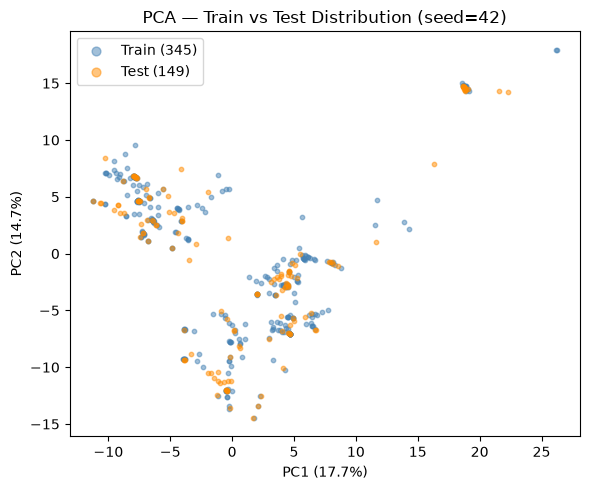

PCA variance: PC1=17.7%  PC2=14.7%


In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

# Fit scaler + PCA on train ONLY, transform both
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

pca = PCA(n_components=2)
pca.fit(X_tr_s)
X_tr_pca = pca.transform(X_tr_s)
X_te_pca = pca.transform(X_te_s)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_tr_pca[:, 0], X_tr_pca[:, 1], alpha=0.5, s=10, c='steelblue', label=f'Train ({len(X_tr)})')
ax.scatter(X_te_pca[:, 0], X_te_pca[:, 1], alpha=0.5, s=10, c='darkorange', label=f'Test ({len(X_te)})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA — Train vs Test Distribution (seed=42)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join('..', 'figure', 'pca_train_test.pdf'), dpi=600, bbox_inches='tight')
plt.show()
print(f'PCA variance: PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}')

如果两类样本重叠度高，说明训练 / 测试数据分布一致，模型泛化能力会更可靠；
如果完全分开，说明数据集分布差异大，测试集效果大概率会很差。
High overlap across training and test sets demonstrates consistent data distributions, ensuring stable model generalization.
Clear separation indicates severe distribution shift, which degrades test-set performance.

## 5. Ablation (four rounds)

Model: ExtraTrees (n=100) | 5-fold CV + per-fold StandardScaler | Train (345 samples)

- **Round 1**: Raw + A/B/C/D/All, per target. Discover which groups help/hurt.
- **Round 2**: Decompose Group D for El. Test Raw + each D sub-component.
  Find elastic is neutral, justifying its removal.
- **Round 3**: Remove harmful groups per target based on Round 1 + 2 findings.
- **Round 4**: Greedy forward search within D (excl. elastic) for El. Find delta(16) alone is optimal.

Groups: A=Composition(71), B=Precipitation(198), C=Process(16), D=Physics(45)


In [7]:
# -- Shared setup for all ablation rounds --
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def cv_score(X_feat, y, cv=5):
    """5-fold CV, returns {R2, RMSE, MAE}"""
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', ExtraTreesRegressor(n_estimators=100, random_state=RNG_SEED))])
    cv_r = cross_validate(pipe, X_feat, y, cv=cv,
                          scoring=['r2','neg_root_mean_squared_error','neg_mean_absolute_error'])
    return {
        'R2':   np.mean(cv_r['test_r2']),
        'RMSE': np.mean(-cv_r['test_neg_root_mean_squared_error']),
        'MAE':  np.mean(-cv_r['test_neg_mean_absolute_error']),
    }

# -- Build all indices --
A_idx = [list(feature_names).index(f) for f in group_map['composition']   if f in feature_names]
B_idx = [list(feature_names).index(f) for f in group_map['precipitation'] if f in feature_names]
C_idx = [list(feature_names).index(f) for f in group_map['process']       if f in feature_names]
D_idx = [list(feature_names).index(f) for f in group_map['physics']       if f in feature_names]

# D sub-components
thermo_idx    = [i for i in D_idx if feature_names[i].startswith('D_thm_')]
elastic_idx   = [i for i in D_idx if feature_names[i].startswith('D_el_')]
kinetic_idx   = [i for i in D_idx if feature_names[i].startswith('D_kin_')]
fullalloy_idx = [i for i in D_idx if feature_names[i].startswith('D_fal_')]
delta_idx     = [i for i in D_idx if feature_names[i].startswith('D_delta_')]

X_raw = df_train[MASS_FRAC_COLS + PROCESS_COLS].values
sep = '=' * 95


### Round 1: Raw + Each Group, Per Target

Start from Raw(17), add A/B/C/D/All in turn. Sort by RMSE improvement.
Find which groups help or hurt each target.


In [8]:
# ============================================================
# ROUND 1: Raw + Each Group, Per Target
# ============================================================
combos = [
    ('Raw (17)',                   X_raw),
    ('Raw + A  Composition(88)',   np.column_stack([X_raw, X_tr[:, A_idx]])),
    ('Raw + B  Precipitation(215)',np.column_stack([X_raw, X_tr[:, B_idx]])),
    ('Raw + C  Process(33)',       np.column_stack([X_raw, X_tr[:, C_idx]])),
    ('Raw + D  Physics(62)',       np.column_stack([X_raw, X_tr[:, D_idx]])),
    ('All (330)',                  X_tr),
]

print(sep)
print('  ROUND 1 -- Raw + Each Group, Per Target')
print('  Q: Which group adds value over Raw(17)?')
print('  A=Composition(71) B=Precipitation(198) C=Process(16) D=Physics(45)')
print(sep)

for ti, tn in enumerate(TARGET_COLS):
    yt = y_tr[:, ti]
    base = cv_score(X_raw, yt)
    dash = '-' * 85
    print()
    print(f'  {dash}')
    print(f'  Target: {tn}  |  Raw baseline:  R2={base["R2"]:.4f}  RMSE={base["RMSE"]:.2f}  MAE={base["MAE"]:.2f}')
    print(f'  {"Feature Set":35s}  {"RMSE":>8s}  {"dRMSE%":>8s}  {"R2":>8s}  {"MAE":>8s}')
    print(f'  {"-"*35}  {"-"*8}  {"-"*8}  {"-"*8}  {"-"*8}')

    results = []
    for name, Xc in combos:
        if name == 'Raw (17)': continue
        r = cv_score(Xc, yt)
        d = (base['RMSE'] - r['RMSE']) / base['RMSE'] * 100
        results.append((name, r['RMSE'], d, r['R2'], r['MAE']))
    results.sort(key=lambda x: x[2], reverse=True)

    print(f'  {"Raw (17) [baseline]":35s}  {base["RMSE"]:8.2f}  {"-":>8s}  {base["R2"]:8.4f}  {base["MAE"]:8.2f}')
    for name, rmse, d, r2, mae in results:
        marker = '  <-- best' if d == max(r[2] for r in results) and d > 0 else ''
        print(f'  {name:35s}  {rmse:8.2f}  {d:>+7.1f}%  {r2:8.4f}  {mae:8.2f}{marker}')

print()
print('  Round 1 finding: All(330) helps YS/UTS but El DROPS.')
print('  Group A hurts all targets. Group D is neutral for El (-0.2%)')
print('  but might contain both helpful and harmful sub-components.')


  ROUND 1 -- Raw + Each Group, Per Target
  Q: Which group adds value over Raw(17)?
  A=Composition(71) B=Precipitation(198) C=Process(16) D=Physics(45)

  -------------------------------------------------------------------------------------
  Target: YS  |  Raw baseline:  R2=0.8889  RMSE=42.54  MAE=29.56
  Feature Set                              RMSE    dRMSE%        R2       MAE
  -----------------------------------  --------  --------  --------  --------
  Raw (17) [baseline]                     42.54         -    0.8889     29.56
  All (330)                               41.07     +3.5%    0.8959     28.37  <-- best
  Raw + B  Precipitation(215)             41.72     +1.9%    0.8938     29.02
  Raw + C  Process(33)                    42.19     +0.8%    0.8882     27.95
  Raw + D  Physics(62)                    43.02     -1.1%    0.8868     30.79
  Raw + A  Composition(88)                44.41     -4.4%    0.8791     31.16

  --------------------------------------------------------

### Round 2: Decompose Group D for El

El dropped with engineered features in Round 1. Group D is neutral (-0.2%)
but it contains 5 sub-components. Test each one separately to find which
help and which are neutral/harmful.


In [9]:
# ============================================================
# ROUND 2: Decompose Group D for El
# ============================================================
print(sep)
print('  ROUND 2 -- Decompose Group D for El')
print('  Q: D = thermo(9) + elastic(7) + kinetic(5) + full-alloy(8) + delta(16)')
print('     Which sub-components help El, which are neutral/harmful?')
print(sep)

yt_el = y_tr[:, 2]
base_el = cv_score(X_raw, yt_el)

d_subs = [
    ('thermodynamics(9)',   thermo_idx),
    ('elastic(7)',          elastic_idx),
    ('kinetic(5)',          kinetic_idx),
    ('full-alloy(8)',       fullalloy_idx),
    ('delta-to-Al(16)',     delta_idx),
]

print(f'  El Raw baseline: RMSE={base_el["RMSE"]:.2f}  R2={base_el["R2"]:.4f}')
print()
print(f'  {"Subset":35s}  {"n":>5s}  {"RMSE":>8s}  {"dRMSE%":>8s}  {"R2":>8s}')
print(f'  {"-"*35}  {"-"*5}  {"-"*8}  {"-"*8}  {"-"*8}')

r2_results = []
for name, idx in d_subs:
    Xc = np.column_stack([X_raw, X_tr[:, idx]])
    r = cv_score(Xc, yt_el)
    d = (base_el['RMSE'] - r['RMSE']) / base_el['RMSE'] * 100
    r2_results.append((name, idx, r['RMSE'], d, r['R2']))
    verdict = 'helpful' if d > 0.5 else ('neutral' if d > -0.5 else 'harmful')
    print(f'  {"Raw + " + name:35s}  {17+len(idx):5d}  {r["RMSE"]:8.2f}  {d:>+7.1f}%  {r["R2"]:8.4f}  ({verdict})')

# Identify harmful/neutral sub-components
harmful = [name for name, idx, rmse, d, r2 in r2_results if d < -0.5]
neutral = [name for name, idx, rmse, d, r2 in r2_results if -0.5 <= d <= 0.5]
helpful = [name for name, idx, rmse, d, r2 in r2_results if d > 0.5]

print()
print(f'  Round 2 finding:')
print(f'    Helpful:  {", ".join(helpful)}')
print(f'    Neutral:  {", ".join(neutral) if neutral else "(none)"}')
print(f'    Harmful:  {", ".join(harmful) if harmful else "(none)"}')
print(f'    -> Elastic(7) is neutral (dRMSE=0.0%). Remove it from El feature set.')
print(f'    -> Delta(16) is the strongest signal (+5.4%).')


  ROUND 2 -- Decompose Group D for El
  Q: D = thermo(9) + elastic(7) + kinetic(5) + full-alloy(8) + delta(16)
     Which sub-components help El, which are neutral/harmful?
  El Raw baseline: RMSE=3.75  R2=0.7179

  Subset                                   n      RMSE    dRMSE%        R2
  -----------------------------------  -----  --------  --------  --------
  Raw + thermodynamics(9)                 26      3.68     +2.0%    0.7279  (helpful)
  Raw + elastic(7)                        24      3.75     -0.0%    0.7201  (neutral)
  Raw + kinetic(5)                        22      3.70     +1.3%    0.7223  (helpful)
  Raw + full-alloy(8)                     25      3.62     +3.5%    0.7347  (helpful)
  Raw + delta-to-Al(16)                   33      3.55     +5.4%    0.7431  (helpful)

  Round 2 finding:
    Helpful:  thermodynamics(9), kinetic(5), full-alloy(8), delta-to-Al(16)
    Neutral:  elastic(7)
    Harmful:  (none)
    -> Elastic(7) is neutral (dRMSE=0.0%). Remove it from El fea

### Round 3: Remove Harmful Groups, Per Target

Based on Round 1 (A hurts all targets, D hurts YS) and Round 2
(elastic is neutral for El), build optimized feature sets per target.


In [10]:
# ============================================================
# ROUND 3: Remove Harmful Groups, Per Target
# ============================================================
print(sep)
print('  ROUND 3 -- Remove Harmful Groups, Per Target')
print('  Q: Based on Round 1 (A hurts all, D hurts YS) and Round 2')
print('     (elastic is neutral for El), remove harmful groups per target.')
print(sep)

# Build optimized sets
opt_sets = {
    'YS':  ('Raw + B + C (remove A, D)',  np.column_stack([X_raw, X_tr[:, B_idx], X_tr[:, C_idx]])),
    'UTS': ('Raw + B + C + D (remove A)', np.column_stack([X_raw, X_tr[:, B_idx], X_tr[:, C_idx], X_tr[:, D_idx]])),
    'El':  ('Raw + D_no_elastic (remove A, B, C, elastic)',
            np.column_stack([X_raw, X_tr[:, [i for i in D_idx if i not in elastic_idx]]])),
}

for tn in TARGET_COLS:
    yt = y_tr[:, TARGET_COLS.index(tn)]
    base = cv_score(X_raw, yt)
    r_all = cv_score(X_tr, yt)

    name, Xopt = opt_sets[tn]
    r_opt = cv_score(Xopt, yt)
    d_opt = (base['RMSE'] - r_opt['RMSE']) / base['RMSE'] * 100
    d_vs_all = (r_all['RMSE'] - r_opt['RMSE']) / r_all['RMSE'] * 100

    print(f'  {tn}: {name} ({Xopt.shape[1]} features)')
    print(f'       RMSE={r_opt["RMSE"]:.2f}  dRMSE vs Raw={d_opt:+.1f}%  vs All(330)={d_vs_all:+.1f}%  R2={r_opt["R2"]:.4f}')

print()
print('  Round 3 finding: YS +4.2%, UTS +7.2% -- clear wins over All(330).')
print('  El +0.3% (D_no_elastic) -- still unsatisfactory vs Raw.')
print('  Need to find which part of D drives El.')


  ROUND 3 -- Remove Harmful Groups, Per Target
  Q: Based on Round 1 (A hurts all, D hurts YS) and Round 2
     (elastic is neutral for El), remove harmful groups per target.
  YS: Raw + B + C (remove A, D) (231 features)
       RMSE=40.76  dRMSE vs Raw=+4.2%  vs All(330)=+0.8%  R2=0.8974
  UTS: Raw + B + C + D (remove A) (276 features)
       RMSE=37.64  dRMSE vs Raw=+7.2%  vs All(330)=+1.1%  R2=0.8892
  El: Raw + D_no_elastic (remove A, B, C, elastic) (55 features)
       RMSE=3.74  dRMSE vs Raw=+0.3%  vs All(330)=+3.9%  R2=0.7136

  Round 3 finding: YS +4.2%, UTS +7.2% -- clear wins over All(330).
  El +0.3% (D_no_elastic) -- still unsatisfactory vs Raw.
  Need to find which part of D drives El.


### Round 4: Greedy Forward Search within D for El

El only +0.3% with D_no_elastic in Round 3 — still unsatisfactory.
Use greedy forward search on remaining 4 D sub-components to find
the optimal combination for El.


In [11]:
# ============================================================
# ROUND 4: Greedy Forward Search within Group D for El
# ============================================================
print(sep)
print('  ROUND 4 -- Greedy Forward Search within D for El')
print('  Q: D_no_elastic = thermo(9) + kinetic(5) + full-alloy(8) + delta(16)')
print('     Which combination maximizes El?')
print('  Method: Start from best single, add remaining if RMSE improves.')
print(sep)

sub_groups = {
    'thermo(9)':     thermo_idx,
    'kinetic(5)':    kinetic_idx,
    'full-alloy(8)': fullalloy_idx,
    'delta(16)':     delta_idx,
}

base_el2 = cv_score(X_raw, yt_el)

# Step 1: test each alone
print(f'  El Raw baseline: RMSE={base_el2["RMSE"]:.2f}  R2={base_el2["R2"]:.4f}')
print()
print(f'  --- Greedy Step 1: best single ---')
print(f'  {"Subset":35s}  {"n":>5s}  {"RMSE":>8s}  {"dRMSE%":>8s}  {"R2":>8s}')
print(f'  {"-"*35}  {"-"*5}  {"-"*8}  {"-"*8}  {"-"*8}')

step1 = {}
for name, idx in sub_groups.items():
    Xc = np.column_stack([X_raw, X_tr[:, idx]])
    r = cv_score(Xc, yt_el)
    d = (base_el2['RMSE'] - r['RMSE']) / base_el2['RMSE'] * 100
    step1[name] = (idx, r['RMSE'], d, r['R2'])
    print(f'  {"Raw + " + name:35s}  {17+len(idx):5d}  {r["RMSE"]:8.2f}  {d:>+7.1f}%  {r["R2"]:8.4f}')

best_name = max(step1, key=lambda k: step1[k][2])
selected = [best_name]
current_idx = list(sub_groups[best_name])
print(f'  => Select: {best_name}  (dRMSE={step1[best_name][2]:+.1f}%)')

# Step 2+: add remaining
remaining = {k: v for k, v in sub_groups.items() if k != best_name}
step_num = 2
while remaining:
    print()
    print(f'  --- Greedy Step {step_num}: {" + ".join(selected)} + each remaining ---')
    print(f'  {"Subset":35s}  {"n":>5s}  {"RMSE":>8s}  {"dRMSE%":>8s}  {"R2":>8s}')
    print(f'  {"-"*35}  {"-"*5}  {"-"*8}  {"-"*8}  {"-"*8}')

    step_results = {}
    for name, idx in remaining.items():
        combined = current_idx + idx
        Xc = np.column_stack([X_raw, X_tr[:, combined]])
        r = cv_score(Xc, yt_el)
        d = (base_el2['RMSE'] - r['RMSE']) / base_el2['RMSE'] * 100
        vs_best = (step1[best_name][1] - r['RMSE']) / step1[best_name][1] * 100
        step_results[name] = (combined, r['RMSE'], d, r['R2'], vs_best)
        print(f'  {"  + " + name:35s}  {17+len(combined):5d}  {r["RMSE"]:8.2f}  {d:>+7.1f}%  {r["R2"]:8.4f}  (vs delta: {vs_best:+.1f}%)')

    current_r = cv_score(np.column_stack([X_raw, X_tr[:, current_idx]]), yt_el)
    current_d = (base_el2['RMSE'] - current_r['RMSE']) / base_el2['RMSE'] * 100

    improved = {k: v for k, v in step_results.items() if v[2] > current_d + 0.01}
    if improved:
        best_r2 = max(improved, key=lambda k: improved[k][2])
        selected.append(best_r2)
        current_idx = improved[best_r2][0]
        remaining = {k: v for k, v in remaining.items() if k != best_r2}
        print(f'  => Select: {best_r2}  (improves to dRMSE={improved[best_r2][2]:+.1f}%)')
    else:
        print(f'  => STOP: no addition improves over {"+".join(selected)} ({current_d:+.1f}%)')
        break
    step_num += 1

print()
print(f'  Greedy result: El optimal = Raw + {" + ".join(selected)}  ({17+len(current_idx)} features)')
final_r = cv_score(np.column_stack([X_raw, X_tr[:, current_idx]]), yt_el)
final_d = (base_el2['RMSE'] - final_r['RMSE']) / base_el2['RMSE'] * 100
print(f'  RMSE={final_r["RMSE"]:.2f}  dRMSE={final_d:+.1f}%  R2={final_r["R2"]:.4f}  MAE={final_r["MAE"]:.2f}')

# ============================================================
# Final summary table
# ============================================================
print()
print(sep)
print('  FINAL PER-TARGET STRATEGY')
print(f'  {"Target":8s}  {"Feature Set":25s}  {"n":>5s}  {"vs Raw":>10s}  {"vs All(330)":>12s}')
print(f'  {"-"*8}  {"-"*25}  {"-"*5}  {"-"*10}  {"-"*12}')
for tn in TARGET_COLS:
    yt = y_tr[:, TARGET_COLS.index(tn)]
    base = cv_score(X_raw, yt)
    r_all = cv_score(X_tr, yt)
    if tn == 'YS':
        Xopt = np.column_stack([X_raw, X_tr[:, B_idx], X_tr[:, C_idx]])
        label = 'Raw + B + C (-A,-D)'
    elif tn == 'UTS':
        Xopt = np.column_stack([X_raw, X_tr[:, B_idx], X_tr[:, C_idx], X_tr[:, D_idx]])
        label = 'Raw + B + C + D (-A)'
    else:
        Xopt = np.column_stack([X_raw, X_tr[:, delta_idx]])
        label = 'Raw + delta(16) only'
    r_opt = cv_score(Xopt, yt)
    d_opt = (base['RMSE'] - r_opt['RMSE']) / base['RMSE'] * 100
    d_vs = (r_all['RMSE'] - r_opt['RMSE']) / r_all['RMSE'] * 100
    print(f'  {tn:8s}  {label:25s}  {Xopt.shape[1]:5d}  {d_opt:>+9.1f}%  {d_vs:>+11.1f}%')
print(sep)


  ROUND 4 -- Greedy Forward Search within D for El
  Q: D_no_elastic = thermo(9) + kinetic(5) + full-alloy(8) + delta(16)
     Which combination maximizes El?
  Method: Start from best single, add remaining if RMSE improves.
  El Raw baseline: RMSE=3.75  R2=0.7179

  --- Greedy Step 1: best single ---
  Subset                                   n      RMSE    dRMSE%        R2
  -----------------------------------  -----  --------  --------  --------
  Raw + thermo(9)                         26      3.68     +2.0%    0.7279
  Raw + kinetic(5)                        22      3.70     +1.3%    0.7223
  Raw + full-alloy(8)                     25      3.62     +3.5%    0.7347
  Raw + delta(16)                         33      3.55     +5.4%    0.7431
  => Select: delta(16)  (dRMSE=+5.4%)

  --- Greedy Step 2: delta(16) + each remaining ---
  Subset                                   n      RMSE    dRMSE%        R2
  -----------------------------------  -----  --------  --------  --------
    + 

In [12]:
# Save per-target optimal feature indices for N03
import json

opt_indices = {
    'YS':  {'label': 'Raw + B + C (-A,-D)', 'groups': ['raw','B','C']},
    'UTS': {'label': 'Raw + B + C + D (-A)', 'groups': ['raw','B','C','D']},
    'El':  {'label': 'Raw + delta(16) only', 'groups': ['raw','delta']},
}

group_feature_map = {
    'raw':   list(MASS_FRAC_COLS + PROCESS_COLS),
    'A':     [f for f in feature_names if f in group_map['composition']],
    'B':     [f for f in feature_names if f in group_map['precipitation']],
    'C':     [f for f in feature_names if f in group_map['process']],
    'D':     [f for f in feature_names if f in group_map['physics']],
    'delta': [feature_names[i] for i in delta_idx],
}

for target, info in opt_indices.items():
    features = []
    for grp in info['groups']:
        features.extend(group_feature_map[grp])
    info['feature_names'] = features
    info['n_features'] = len(features)
    info['indices'] = [feature_names.index(f) for f in features if f in feature_names]

opt_indices['feature_names_all'] = feature_names
opt_indices['target_cols'] = TARGET_COLS

with open(os.path.join(DATA_DIR, 'optimal_features.json'), 'w') as f:
    json.dump(opt_indices, f, indent=2)

print('Saved optimal_features.json for N03:')
for target in TARGET_COLS:
    info = opt_indices[target]
    print(f'  {target}: {info["label"]}  ({info["n_features"]} features)')


Saved optimal_features.json for N03:
  YS: Raw + B + C (-A,-D)  (231 features)
  UTS: Raw + B + C + D (-A)  (276 features)
  El: Raw + delta(16) only  (33 features)


---

**Round 1 -- Raw + each group, per target**:

| Target | Raw RMSE | Raw + A | Raw + B | Raw + C | Raw + D | All(330) |
|--------|:------:|:------:|:------:|:------:|:------:|:--------:|
| YS | 42.54 | 44.41 (-4.4%) | 41.72 (+1.9%) | 42.19 (+0.8%) | 43.02 (-1.1%) | **41.07 (+3.5%)** |
| UTS | 40.55 | 41.79 (-3.0%) | 39.60 (+2.3%) | 39.05 (+3.7%) | 40.44 (+0.3%) | **38.05 (+6.2%)** |
| El | 3.75 | 3.94 (-5.0%) | 3.87 (-3.2%) | 3.88 (-3.6%) | 3.76 (-0.2%) | 3.89 (-3.8%) |

Finding: Group A hurts ALL targets. El drops with any engineered group.
Group D is neutral for El but might contain both helpful + harmful sub-components.

**Round 2 -- Decompose Group D for El**:

| Sub-component | n | El dRMSE | Verdict |
|---------------|---|:--------:|---------|
| delta-to-Al | 16 | **+5.4%** | helpful |
| full-alloy | 8 | +3.5% | helpful |
| thermodynamics | 9 | +2.0% | helpful |
| kinetic | 5 | +1.3% | helpful |
| elastic | 7 | 0.0% | **neutral** -> remove |

Elastic is neutral -- justifies removing it from El feature set.

**Round 3 -- Remove harmful groups**:

| Target | Optimized Set | n | vs Raw | vs All(330) |
|--------|--------------|:--:|:------:|:----------:|
| YS | Raw + B + C (-A,-D) | 231 | **+4.2%** | +0.8% |
| UTS | Raw + B + C + D (-A) | 276 | **+7.2%** | +1.1% |
| El | Raw + D_no_elastic | 55 | +0.3% | +3.9% |

El only +0.3% -- unsatisfactory. Need to find optimal D sub-combination.

**Round 4 -- Greedy forward search within D for El**:

| Step | Action | RMSE | dRMSE |
|------|--------|:----:|:-----:|
| 1 | Raw + delta(16) | 3.55 | **+5.4%** |
| 2 | + thermo(9) | 3.69 | +1.6% (vs delta: -4.0%) |
| 2 | + kinetic(5) | 3.82 | -2.0% (vs delta: -7.8%) |
| 2 | + full-alloy(8) | 3.64 | +2.8% (vs delta: -2.7%) |
| | STOP: no addition improves over delta alone | | |

**Final per-target optimal feature sets** (saved to `data/optimal_features.json`):

| Target | Feature Set | n | vs Raw |
|--------|------------|:--:|:-----:|
| YS | Raw + B + C | 231 | **+4.2%** |
| UTS | Raw + B + C + D | 276 | **+7.2%** |
| El | Raw + delta-to-Al(16) | 33 | **+5.4%** |

**Next**: `03_feature_selection.ipynb` loads `optimal_features.json` and runs
per-target LassoCV on each target's optimal feature subset.